# Project Information
Project Name
Mental Health in Tech Survey Analysis

Project Type
Exploratory Data Analysis (EDA) & Data Visualization Project

Contribution
Data Cleaning, Exploratory Data Analysis, Data Visualization, Insight Generation, and Streamlit Dashboard Development

Project Summary
Mental Health in Tech Survey Analysis is a data analytics project focused on understanding mental health conditions and attitudes toward mental health in the technology workplace. The project uses survey data containing demographic information, employment characteristics, mental health history, treatment-seeking behaviour, workplace support, and employees' perceptions of mental health. The analysis aims to identify meaningful patterns across different groups and explore factors associated with mental health and workplace attitudes.

GitHub Link
https://github.com/Mohd-NasrullahSidd1137/Mental-Health-Survey-App

Problem Statement
Mental health is an important aspect of employee well-being, particularly in the technology workplace. Employees may experience mental health conditions while also facing challenges related to workplace support, treatment accessibility, confidentiality, and communication.
The objective of this project is to analyze survey data to understand how mental health conditions and attitudes toward mental health vary among employees. The analysis will also explore which factors may be associated with mental health treatment and workplace attitudes. The project specifically encourages investigation of geographic differences and the strongest predictors of mental health illness or workplace attitudes.

Business Objective
The main objective of this project is to analyze mental health patterns in the technology workplace and generate data-driven insights that can help organizations understand employee needs and improve workplace mental-health support.

The analysis will focus on:
Understanding mental health patterns across different demographic and geographic groups.
Analyzing the relationship between family history, treatment, employment characteristics, and workplace environment.
Studying employees' awareness and access to mental health benefits and resources.
Identifying factors associated with employees seeking mental health treatment.
Developing meaningful visualizations and an interactive Streamlit application to communicate the findings.

In [3]:
# STEP 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
#STEP 2 — Load Dataset

df = pd.read_csv("C:\\Users\\dell\\OneDrive\\Desktop\\Labmentix Intership\\Mental Health Survey Report\\survey.csv")
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
df.head()

Number of Rows: 1259
Number of Columns: 27


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [5]:
# Dataset Overview

# Display all column names

print("Total Columns:", len(df.columns))
print("\nColumn Names:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Total Columns: 27

Column Names:

1. Timestamp
2. Age
3. Gender
4. Country
5. state
6. self_employed
7. family_history
8. treatment
9. work_interfere
10. no_employees
11. remote_work
12. tech_company
13. benefits
14. care_options
15. wellness_program
16. seek_help
17. anonymity
18. leave
19. mental_health_consequence
20. phys_health_consequence
21. coworkers
22. supervisor
23. mental_health_interview
24. phys_health_interview
25. mental_vs_physical
26. obs_consequence
27. comments


In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [8]:
# Statistical summary of numerical columns

df.describe()

# Statistical summary of categorical columns

df.describe(include="object")

,Timestamp,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
count,1259,1259,1259,744,1241,1259,1259,995,1259,1259,...,1259,1259,1259,1259,1259,1259,1259,1259,1259,164
unique,1246,49,48,45,2,2,2,4,6,2,...,5,3,3,3,3,3,3,3,2,160
top,2014-08-27 12:43:28,Male,United States,CA,No,No,Yes,Sometimes,6-25,No,...,Don't know,No,No,Some of them,Yes,No,Maybe,Don't know,No,* Small family business - YMMV.
freq,2,615,751,138,1095,767,637,465,290,883,...,563,490,925,774,516,1008,557,576,1075,5


In [11]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


In [12]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64


In [13]:
# Calculate missing values percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

print("Missing Values Summary:\n")
display(missing_summary)

Missing Values Summary:



,Missing Values,Missing Percentage
state,515,40.91
self_employed,18,1.43
work_interfere,264,20.97
comments,1095,86.97


### What did you know about your dataset?

- The dataset contains 1,259 rows and 27 columns.
- The dataset contains 1 numerical column (`Age`) and 26 categorical/object columns.
- No completely duplicate rows were found in the dataset.
- Missing values are present in four columns: `state`, `self_employed`, `work_interfere`, and `comments`.
- The `comments` column has the highest proportion of missing values (86.97%).
- The `state` column has 40.91% missing values.
- The `work_interfere` column has 20.97% missing values.
- The `self_employed` column has only 1.43% missing values.
- The `Age` column contains suspicious extreme values, which will require validation and cleaning during the Data Wrangling stage.
- The `Gender` column contains multiple distinct values and will require further inspection before analysis.

### Variables Description

| Variable | Description |
|---|---|
| Timestamp | Date and time when the survey response was recorded |
| Age | Age of the respondent |
| Gender | Gender identity of the respondent |
| Country | Country where the respondent is located |
| state | State or region of the respondent |
| self_employed | Whether the respondent is self-employed |
| family_history | Whether the respondent has a family history of mental illness |
| treatment | Whether the respondent has sought treatment for a mental health condition |
| work_interfere | Frequency with which mental health issues interfere with work |
| no_employees | Number of employees in the respondent's workplace |
| remote_work | Whether the respondent works remotely |
| tech_company | Whether the respondent works for a technology company |
| benefits | Whether the employer provides mental health benefits |
| care_options | Whether the respondent is aware of available mental health care options |
| wellness_program | Whether the employer offers a mental health wellness program |
| seek_help | Whether the employer provides information about mental health resources |
| anonymity | Whether the respondent's anonymity is protected when seeking mental health treatment |
| leave | Ease of taking medical leave for a mental health condition |
| mental_health_consequence | Expected consequence of discussing mental health issues at work |
| phys_health_consequence | Expected consequence of discussing physical health issues at work |
| coworkers | Willingness of coworkers to discuss mental health |
| supervisor | Willingness of supervisors to discuss mental health |
| mental_health_interview | Willingness to discuss mental health during a job interview |
| phys_health_interview | Willingness to discuss physical health during a job interview |
| mental_vs_physical | Whether mental health is perceived as being treated differently from physical health |
| obs_consequence | Whether the respondent has observed negative consequences for coworkers with mental health conditions |
| comments | Optional additional comments provided by the respondent |

In [15]:
# Display unique values for each column

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


Timestamp:
['2014-08-27 11:29:31' '2014-08-27 11:29:37' '2014-08-27 11:29:44' ...
 '2015-11-07 12:36:58' '2015-11-30 21:25:06' '2016-02-01 23:04:31']

Age:
[         37          44          32          31          33          35
          39          42          23          29          36          27
          46          41          34          30          40          38
          50          24          18          28          26          22
          19          25          45          21         -29          43
          56          60          54         329          55 99999999999
          48          20          57          58          47          62
          51          65          49       -1726           5          53
          61           8          11          -1          72]

Gender:
['Female' 'M' 'Male' 'male' 'female' 'm' 'Male-ish' 'maile' 'Trans-female'
 'Cis Female' 'F' 'something kinda male?' 'Cis Male' 'Woman' 'f' 'Mal'
 'Male (CIS)' 'queer/she/they' 'non-binary

In [16]:
# Convert Timestamp to datetime format

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print("Timestamp converted successfully!")
print(df['Timestamp'].dtype)

Timestamp converted successfully!
datetime64[ns]


In [17]:
# Check minimum and maximum Age values

print("Minimum Age:", df['Age'].min())
print("Maximum Age:", df['Age'].max())

print("\nInvalid Age Values:")
print(df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'].unique())

Minimum Age: -1726
Maximum Age: 99999999999

Invalid Age Values:
[        -29         329 99999999999       -1726           5           8
          11          -1]


In [18]:
# Replace invalid Age values with NaN

df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

print("Invalid Age values replaced with NaN.")
print("Missing Age values:", df['Age'].isnull().sum())


Invalid Age values replaced with NaN.
Missing Age values: 8


In [19]:
# Fill missing Age values with the median age

median_age = df['Age'].median()

df['Age'] = df['Age'].fillna(median_age)

print("Median Age:", median_age)
print("Missing Age values after filling:", df['Age'].isnull().sum())

Median Age: 31.0
Missing Age values after filling: 0


In [20]:
# Check frequency of each Gender value

print("Gender Value Counts:\n")
print(df['Gender'].value_counts(dropna=False))

Gender Value Counts:

Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Male                                                3
Woman                                               3
Cis Male                                            2
Man                                                 2
Female                                              2
Female (trans)                                      2
Male-ish                                            1
Trans-female                                        1
Male (CIS)                                          1

In [21]:
# Standardize Gender values

def clean_gender(gender):
    gender = str(gender).strip().lower()

    # Male categories
    if gender in [
        'm', 'male', 'man', 'make', 'mal', 'maile', 'mail',
        'male-ish', 'male (cis)', 'cis male', 'cis man',
        'msle', 'malr', 'guy (-ish) ^_^',
        'male leaning androgynous',
        'something kinda male?',
        'ostensibly male, unsure what that really means'
    ]:
        return 'Male'

    # Female categories
    elif gender in [
        'f', 'female', 'woman', 'femake', 'femail',
        'cis female', 'female (cis)', 'cis-female/femme'
    ]:
        return 'Female'

    # Transgender categories
    elif gender in ['trans-female', 'trans woman', 'female (trans)']:
        return 'Female'

    # Other / non-binary / gender-diverse responses
    else:
        return 'Other'


df['Gender'] = df['Gender'].apply(clean_gender)

print("Gender standardization completed!")
print("\nCleaned Gender Distribution:\n")
print(df['Gender'].value_counts())

Gender standardization completed!

Cleaned Gender Distribution:

Gender
Male      995
Female    251
Other      13
Name: count, dtype: int64


In [22]:
# Check self-employed distribution including missing values

print("self_employed Value Counts:\n")
print(df['self_employed'].value_counts(dropna=False))

self_employed Value Counts:

self_employed
No     1095
Yes     146
NaN      18
Name: count, dtype: int64


In [23]:
# Fill missing values in self_employed
df['self_employed'] = df['self_employed'].fillna('Unknown')

print("Missing self_employed values after cleaning:", df['self_employed'].isnull().sum())

print("\nCleaned self_employed Distribution:\n")
print(df['self_employed'].value_counts())

Missing self_employed values after cleaning: 0

Cleaned self_employed Distribution:

self_employed
No         1095
Yes         146
Unknown      18
Name: count, dtype: int64


In [24]:
# Fill missing values in state
df['state'] = df['state'].fillna('Unknown')

print("Missing state values after cleaning:", df['state'].isnull().sum())

print("\nState Distribution:\n")
print(df['state'].value_counts())

Missing state values after cleaning: 0

State Distribution:

state
Unknown    515
CA         138
WA          70
NY          57
TN          45
TX          44
OH          30
IL          29
PA          29
OR          29
IN          27
MI          22
MN          21
MA          20
FL          15
VA          14
NC          14
GA          12
MO          12
WI          12
UT          11
CO           9
MD           8
AL           8
AZ           7
NJ           6
OK           6
KY           5
SC           5
CT           4
IA           4
DC           4
NH           3
SD           3
VT           3
KS           3
NV           3
NM           2
WY           2
NE           2
WV           1
ID           1
MS           1
RI           1
LA           1
ME           1
Name: count, dtype: int64


In [25]:
# Check work_interfere distribution including missing values

print("work_interfere Value Counts:\n")
print(df['work_interfere'].value_counts(dropna=False))

work_interfere Value Counts:

work_interfere
Sometimes    465
NaN          264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64


In [26]:
# Fill missing values in work_interfere
df['work_interfere'] = df['work_interfere'].fillna('Unknown')

print("Missing work_interfere values after cleaning:", df['work_interfere'].isnull().sum())

print("\nCleaned work_interfere Distribution:\n")
print(df['work_interfere'].value_counts())

Missing work_interfere values after cleaning: 0

Cleaned work_interfere Distribution:

work_interfere
Sometimes    465
Unknown      264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64


In [27]:
# Check missing values in comments

print("Missing comments:", df['comments'].isnull().sum())
print("Total comments:", df['comments'].notnull().sum())
print("Missing percentage:", round(df['comments'].isnull().mean() * 100, 2), "%")

Missing comments: 1095
Total comments: 164
Missing percentage: 86.97 %


In [28]:
# Final missing value check after data cleaning

missing_values_final = df.isnull().sum()

print("Final Missing Values:\n")
print(missing_values_final[missing_values_final > 0])

Final Missing Values:

comments    1095
dtype: int64


In [29]:
# Final dataset shape and duplicate check

print("Final Number of Rows:", df.shape[0])
print("Final Number of Columns:", df.shape[1])

print("\nDuplicate Rows:", df.duplicated().sum())

Final Number of Rows: 1259
Final Number of Columns: 27

Duplicate Rows: 0


In [30]:
# Final data types check after data cleaning

print("Final Data Types:\n")
print(df.dtypes)

Final Data Types:

Timestamp                    datetime64[ns]
Age                                 float64
Gender                               object
Country                              object
state                                object
self_employed                        object
family_history                       object
treatment                            object
work_interfere                       object
no_employees                         object
remote_work                          object
tech_company                         object
benefits                             object
care_options                         object
wellness_program                     object
seek_help                            object
anonymity                            object
leave                                object
mental_health_consequence            object
phys_health_consequence              object
coworkers                            object
supervisor                           object
mental_health

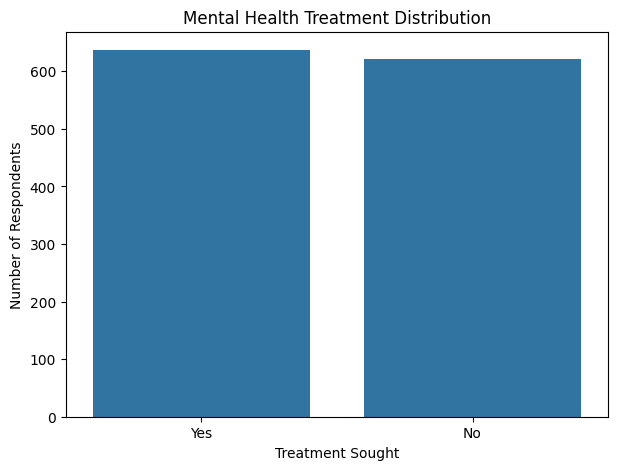

In [31]:
# What is the distribution of respondents who have sought treatment for a mental health condition?


# Chart 1: Mental Health Treatment Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='treatment')

plt.title('Mental Health Treatment Distribution')
plt.xlabel('Treatment Sought')
plt.ylabel('Number of Respondents')

plt.show()

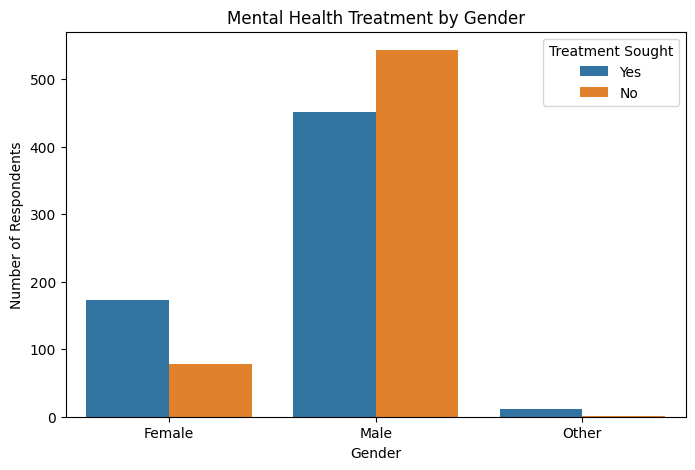

In [33]:

# Chart 2: Mental Health Treatment by Gender

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Gender',
    hue='treatment'
)

plt.title('Mental Health Treatment by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

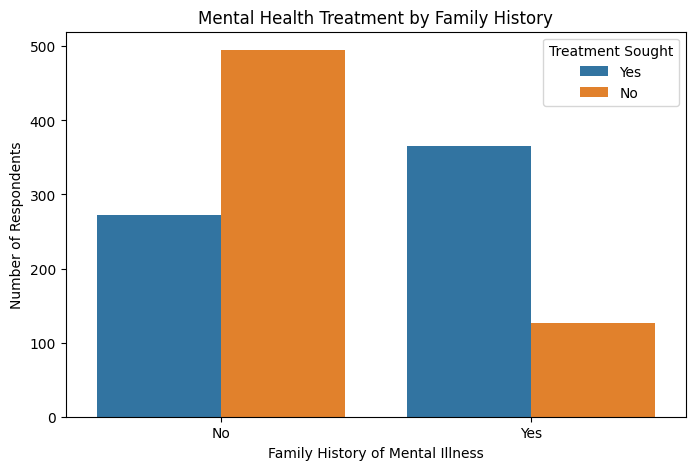

In [34]:
# Chart 3: Mental Health Treatment by Family History

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='family_history',
    hue='treatment'
)

plt.title('Mental Health Treatment by Family History')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

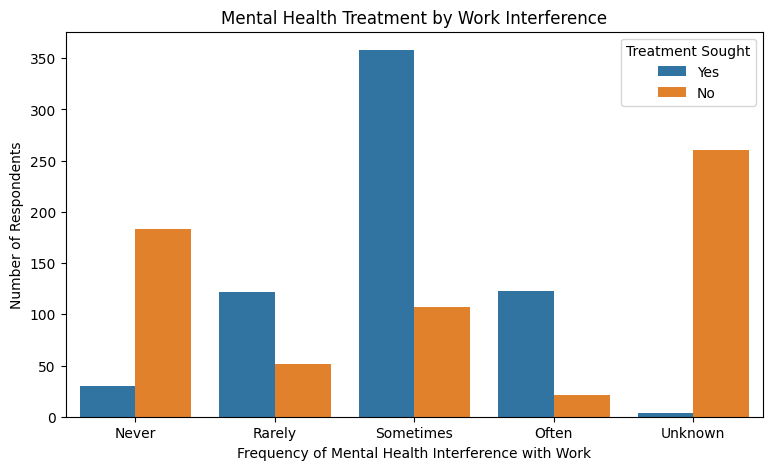

In [35]:
# Chart 4: Mental Health Treatment by Work Interference

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='work_interfere',
    hue='treatment',
    order=['Never', 'Rarely', 'Sometimes', 'Often', 'Unknown']
)

plt.title('Mental Health Treatment by Work Interference')
plt.xlabel('Frequency of Mental Health Interference with Work')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

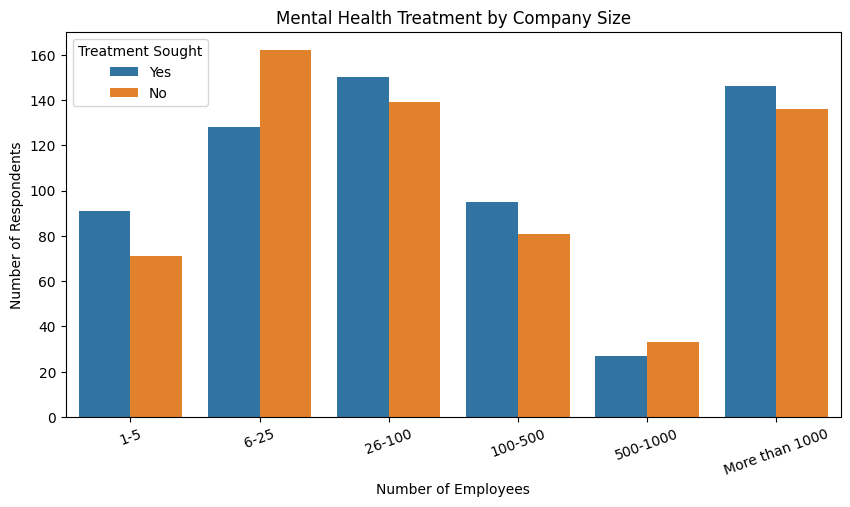

In [36]:
# Chart 5: Mental Health Treatment by Company Size

plt.figure(figsize=(10, 5))

order = [
    '1-5',
    '6-25',
    '26-100',
    '100-500',
    '500-1000',
    'More than 1000'
]

sns.countplot(
    data=df,
    x='no_employees',
    hue='treatment',
    order=order
)

plt.title('Mental Health Treatment by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.xticks(rotation=20)
plt.show()

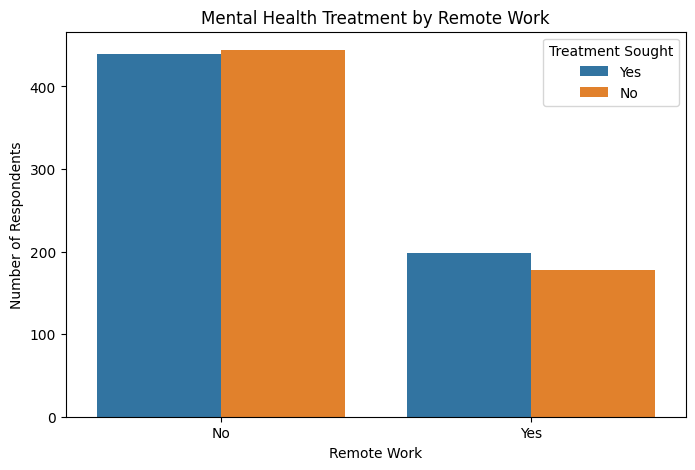

In [37]:
# Chart 6: Mental Health Treatment by Remote Work

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='remote_work',
    hue='treatment'
)

plt.title('Mental Health Treatment by Remote Work')
plt.xlabel('Remote Work')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

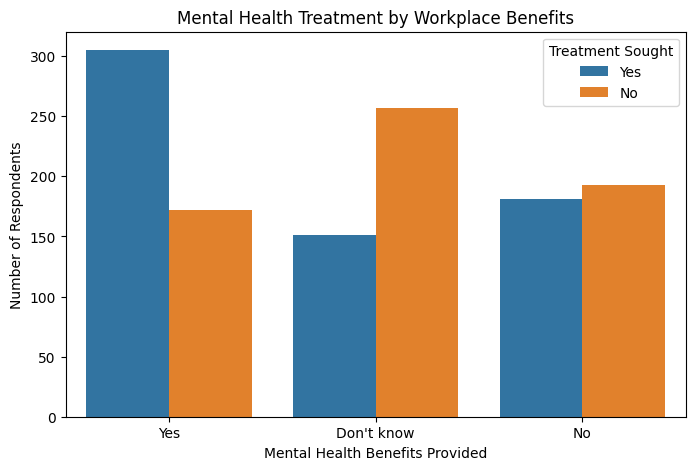

In [38]:
# Chart 7: Mental Health Treatment by Benefits

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='benefits',
    hue='treatment'
)

plt.title('Mental Health Treatment by Workplace Benefits')
plt.xlabel('Mental Health Benefits Provided')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

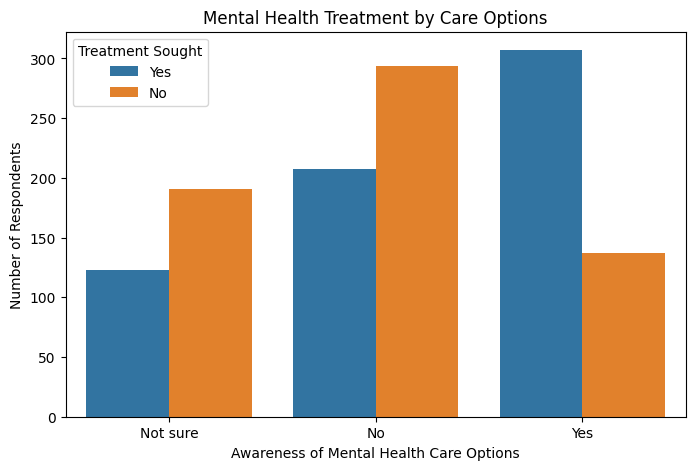

In [39]:
# Chart 8: Mental Health Treatment by Care Options

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='care_options',
    hue='treatment'
)

plt.title('Mental Health Treatment by Care Options')
plt.xlabel('Awareness of Mental Health Care Options')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

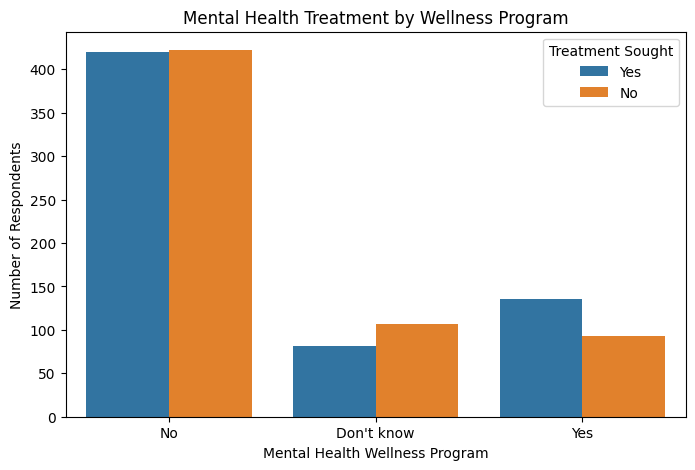

In [40]:
# Chart 9: Mental Health Treatment by Wellness Program

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='wellness_program',
    hue='treatment'
)

plt.title('Mental Health Treatment by Wellness Program')
plt.xlabel('Mental Health Wellness Program')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

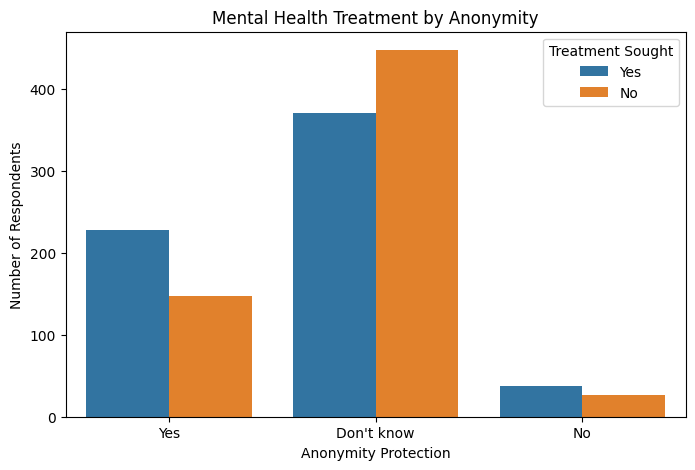

In [41]:
# Chart 10: Mental Health Treatment by Anonymity

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='anonymity',
    hue='treatment'
)

plt.title('Mental Health Treatment by Anonymity')
plt.xlabel('Anonymity Protection')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

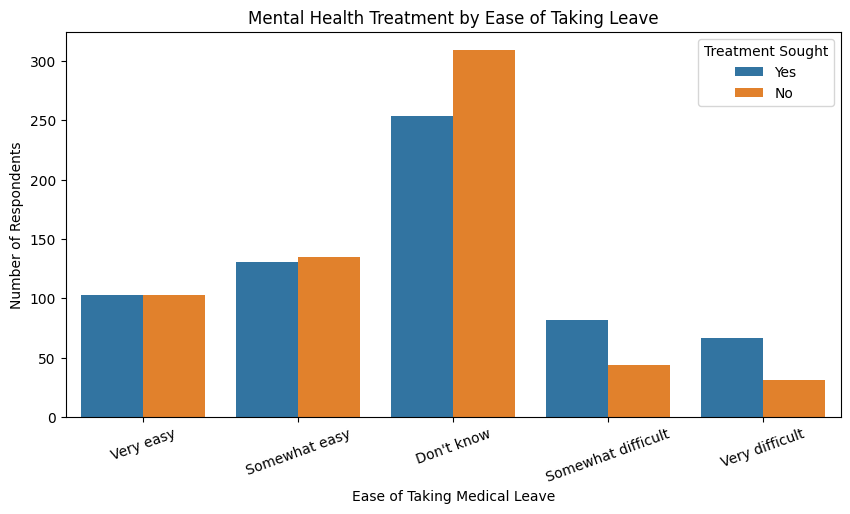

In [42]:
# Chart 11: Mental Health Treatment by Ease of Taking Leave

plt.figure(figsize=(10, 5))

order = [
    'Very easy',
    'Somewhat easy',
    "Don't know",
    'Somewhat difficult',
    'Very difficult'
]

sns.countplot(
    data=df,
    x='leave',
    hue='treatment',
    order=order
)

plt.title('Mental Health Treatment by Ease of Taking Leave')
plt.xlabel('Ease of Taking Medical Leave')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.xticks(rotation=20)
plt.show()

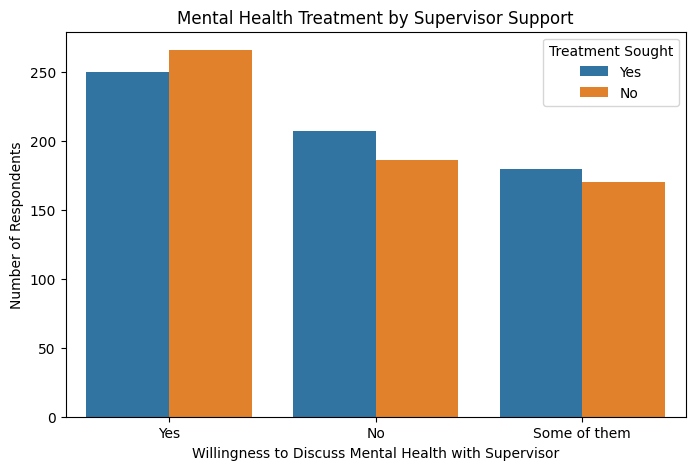

In [43]:
# Chart 12: Mental Health Treatment by Supervisor Support

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='supervisor',
    hue='treatment'
)

plt.title('Mental Health Treatment by Supervisor Support')
plt.xlabel('Willingness to Discuss Mental Health with Supervisor')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

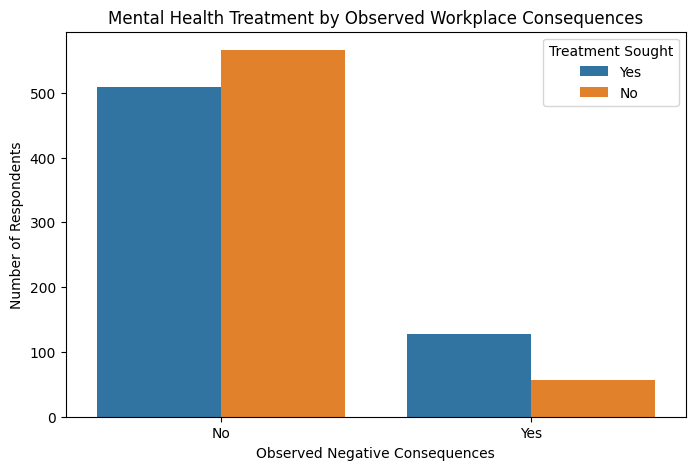

In [44]:
# Chart 13: Mental Health Treatment by Observed Consequences

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='obs_consequence',
    hue='treatment'
)

plt.title('Mental Health Treatment by Observed Workplace Consequences')
plt.xlabel('Observed Negative Consequences')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Sought')

plt.show()

In [45]:
# Create a copy of the dataset for correlation analysis
df_corr = df.copy()

# Convert categorical variables into numerical codes
for column in df_corr.select_dtypes(include='object').columns:
    df_corr[column] = df_corr[column].astype('category').cat.codes

print("Correlation dataset prepared successfully!")
print("Shape:", df_corr.shape)

Correlation dataset prepared successfully!
Shape: (1259, 27)


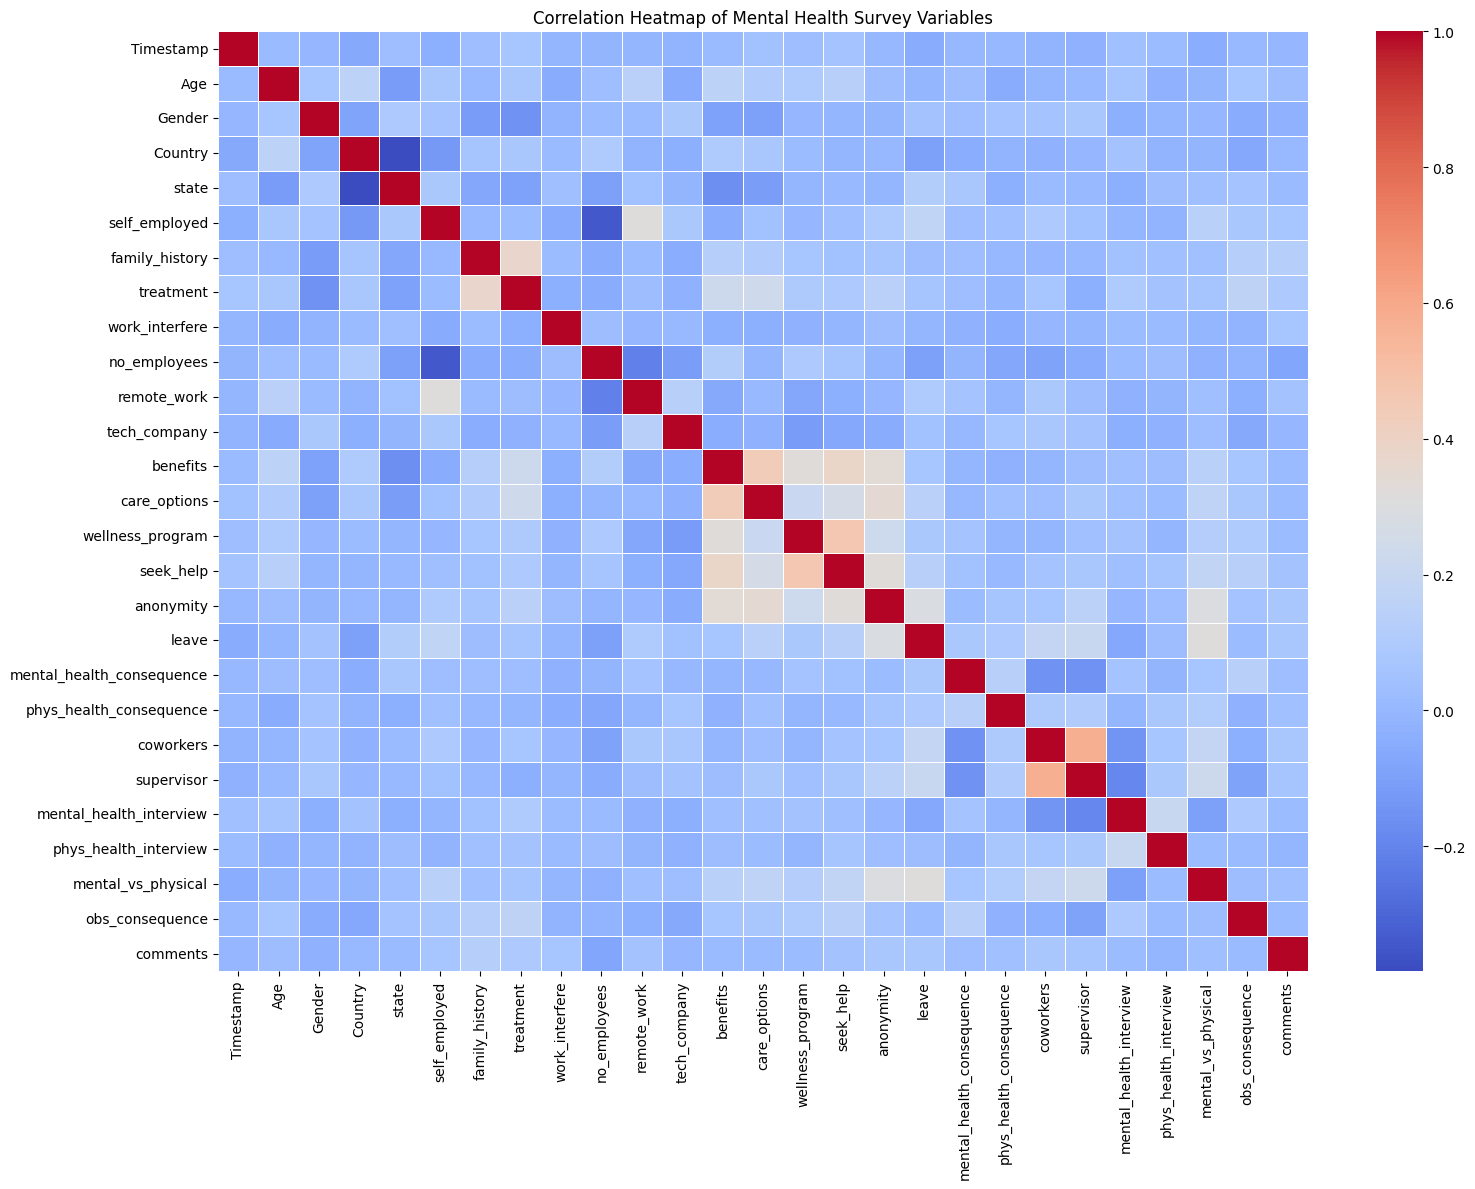

In [46]:
# Chart 14: Correlation Heatmap

correlation_matrix = df_corr.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Mental Health Survey Variables')
plt.tight_layout()
plt.show()

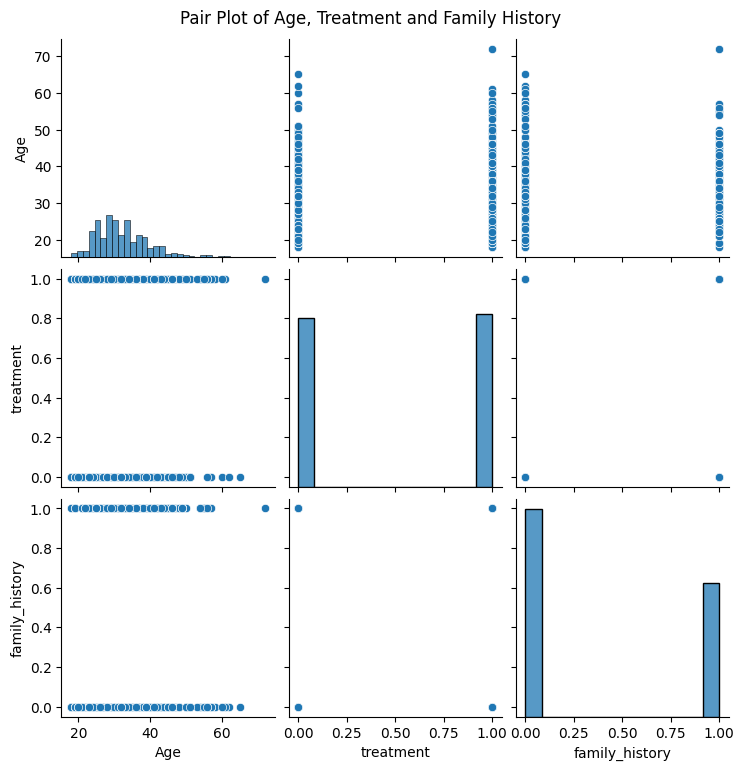

In [47]:
# Chart 15: Pair Plot

pair_df = df[['Age', 'treatment', 'family_history']].copy()

# Convert categorical variables into numerical codes
pair_df['treatment'] = pair_df['treatment'].astype('category').cat.codes
pair_df['family_history'] = pair_df['family_history'].astype('category').cat.codes

sns.pairplot(
    pair_df,
    diag_kind='hist'
)

plt.suptitle('Pair Plot of Age, Treatment and Family History', y=1.02)

plt.show()

## 5. Solution to Business Objective

Based on the exploratory data analysis, the survey provides useful insights
into mental health treatment patterns and workplace attitudes in the
technology sector.

The analysis examined factors such as gender, family history, work
interference, company size, remote work, mental health benefits, care
options, wellness programs, anonymity, medical leave, supervisor support,
and observed workplace consequences.

The analysis indicates that workplace environment and access to mental
health resources are important areas to consider when understanding
employees' mental health experiences. Treatment-seeking behavior can also
be examined alongside personal and workplace characteristics to identify
patterns within the survey data.

Organizations can use these findings to improve awareness of available
mental health resources, strengthen confidential support systems, improve
access to mental health benefits, and create a more supportive workplace
environment.

The analysis is exploratory and identifies associations within the survey
data. These relationships should not be interpreted as evidence of direct
causation.

## Conclusion

The Mental Health in Tech Survey analysis provided insights into mental
health experiences, treatment-seeking behavior, and workplace attitudes
among technology-sector respondents.

The exploratory analysis examined demographic factors, family history,
work-related interference, company characteristics, workplace benefits,
mental health care options, wellness programs, anonymity, leave policies,
supervisor support, and observed workplace consequences.

The data cleaning process addressed invalid age values, standardized
gender categories, handled missing categorical values, and preserved the
optional free-text comments without inappropriate imputation.

Overall, the analysis highlights the importance of accessible mental health
resources, confidentiality, supportive workplace environments, and
employee awareness. These insights can help organizations identify areas
for improving mental health support and workplace policies.

The findings represent patterns and associations in the survey data and
should not be interpreted as proof of causal relationships.